# 2107541 Machine Learning for Environmental Applications
## Lecture 4 : Classification (K-Nearest Neighbours & Model Evaluation)
### Done By : 6730084521 Chatrphol Ovanonchai

## Step 1: Import the dataset 

In [17]:
# Import Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
## scikit-learn imported in cell alr

eutrophic_dataframe = pd.read_csv("./eutrophication_dataset.csv") 
eutrophic_dataframe

,Chlorophyll,Nitrate,Class
0,5,1.0,0
1,7,3.0,0
2,8,2.0,0
3,9,4.0,1
4,10,5.0,0
5,12,2.5,1
6,14,4.0,1
7,16,3.0,0
8,18,5.0,1
9,20,4.5,1


## Step 2: Define `X` (Feature) and `y` (Target)

In [18]:
# Define Feature (X) and Target (Y)
X = eutrophic_dataframe[ ['Chlorophyll','Nitrate'] ] # DataFrame
y = eutrophic_dataframe['Class'] # Series

## Step 3: Scaling
Note that `DecisionTree` and `NaiveBayes` doesn't need scaling

In [19]:
from sklearn.preprocessing import MinMaxScaler ## MixMaxScaler is from preprocessing
scaler = MinMaxScaler() 

## define X_scaled
X_scaled = scaler.fit_transform(X) ## use fit_transform naja -> now it's in np array

## Step 4: Train KNN

In [20]:
from sklearn.neighbors import KNeighborsClassifier ## Don't use NearestNeighbors , use Classifier

## Create Model
knn_model = KNeighborsClassifier(n_neighbors = 5)

## Train Data
knn_model.fit(X_scaled ,y)

KNeighborsClassifier()

## Step 5: Predict

In [21]:
y_predict = knn_model.predict(X_scaled)

In [22]:
y_predict # 0 = Non-Eutrophic , 1 = Eutrophic

array([0, 0, 0, 1, 1, 0, 1, 1, 1, 1])

## Step 6: Confusion Matrix

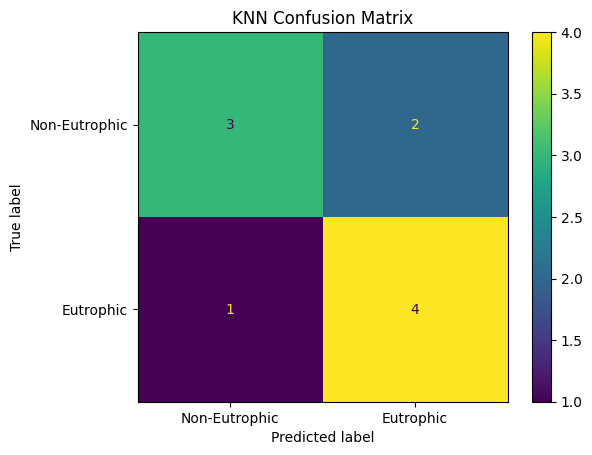

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
## import matplotlib alr

conf_mat = confusion_matrix(y_true = y , y_pred = y_predict) # argument = y_true , y_pred

ConfusionMatrixDisplay(confusion_matrix = conf_mat , display_labels = ['Non-Eutrophic','Eutrophic']).plot()
plt.title("KNN Confusion Matrix")

plt.show() # show all graph

## Step 7: Classification Report

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(y_true = y, y_pred = y_predict, target_names = ['Eutrophic','Non-Eutrophic'])
print(report)

               precision    recall  f1-score   support

    Eutrophic       0.75      0.60      0.67         5
Non-Eutrophic       0.67      0.80      0.73         5

     accuracy                           0.70        10
    macro avg       0.71      0.70      0.70        10
 weighted avg       0.71      0.70      0.70        10



## Extra : KNN Boundary 

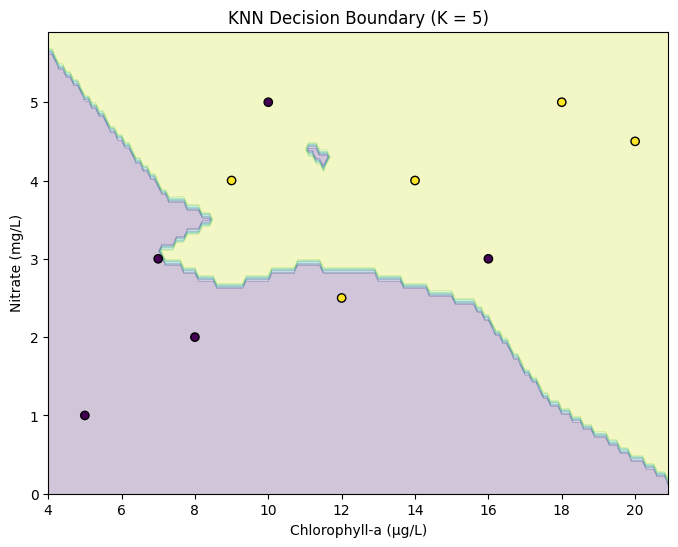

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Create a grid of values
x_min, x_max = X["Chlorophyll"].min() - 1, X["Chlorophyll"].max() + 1
y_min, y_max = X["Nitrate"].min() - 1, X["Nitrate"].max() + 1

xx, yy = np.meshgrid(
 np.arange(x_min, x_max, 0.1),
 np.arange(y_min, y_max, 0.1) )

# Create grid data
grid = pd.DataFrame({
 "Chlorophyll": xx.ravel(),
 "Nitrate": yy.ravel()
})

# Scale 

# Scale the grid using the same scaler
grid_scaled = scaler.transform(grid)

# Predict the class for every point in the grid
Z = knn_model.predict(grid_scaled)
Z = Z.reshape(xx.shape)

# Plot the decision regions
plt.figure(figsize=(8, 6))
plt.contourf(
 xx,
 yy,
 Z,
 alpha=0.25 )

# Plot the original observations
plt.scatter(
 X["Chlorophyll"],
 X["Nitrate"],
 c=y,
 edgecolor="black" )

plt.xlabel("Chlorophyll-a (µg/L)")
plt.ylabel("Nitrate (mg/L)")
plt.title("KNN Decision Boundary (K = 5)")
plt.show()